# Why does the value-growth model work, and when doesn't it?

Notebook 05 established *that* the model ranks players by future value growth with a Spearman correlation around 0.55-0.6, consistently across nine years of walk-forward cutoffs. This notebook asks the harder questions underneath that number:

1. **Is it predicting football, or predicting transfers?** Transfermarkt re-values players straight after a move, usually toward the fee.
2. **Market drift vs. player signal.** How much error is "the whole market moved" rather than "we were wrong about this player"?
3. **Does the eye-test premium get corrected?** Do players valued above their stats subsequently lose value?
4. **Survivorship.** Players who leave the Premier League vanish from the outcome set. Who are they, and what happened to their value?
5. **Momentum or mean reversion?** The value-trend features were the biggest gain. Does "just went up" mean the same thing for a teenager and a star?
6. **The zero-change spike.** Is "not re-valued" informative, and does a two-stage model help?
7. **Relegation.** How much of the model's worst misses are an external shock it can't see?

All the evaluation here is walk-forward, reusing the harness from `src/modeling.py`; the diagnostics live in `src/analysis.py`.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.data_loader import download_dataset
from src.panel import HORIZON_TOLERANCE_DAYS, build_snapshot_panel, load_transfers
from src.modeling import default_backtest_cutoffs, walk_forward_backtest
from src.analysis import flag_transfers_within_horizon, grouped_backtest_metrics

sns.set_theme(style="whitegrid", context="talk")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#888888"

panel = build_snapshot_panel()
data_dir = download_dataset()
cutoffs_12m = default_backtest_cutoffs(panel, months=12)
metrics_12m, preds_12m = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=("xgboost",))
print(f"{len(preds_12m):,} walk-forward predictions across {len(cutoffs_12m)} cutoffs; mean Spearman {metrics_12m['spearman'].mean():.2f}")

14,084 walk-forward predictions across 16 cutoffs; mean Spearman 0.59


## 1. Is the model predicting football, or predicting transfers?

Every player in the evaluation set is flagged by whether they changed club between the snapshot and the end of the outcome window. If the model only works on players who moved, its real skill is anticipating transfers, and its predicted "value growth" is largely the fee being written into the valuation.

In [2]:
transfers_raw = pd.read_csv(data_dir / "transfers.csv", low_memory=False)
transfers_raw["transfer_date"] = pd.to_datetime(transfers_raw["transfer_date"], errors="coerce")

flagged = flag_transfers_within_horizon(preds_12m, transfers_raw, months=12)
by_transfer = grouped_backtest_metrics(flagged, "transferred")

overall = (
    flagged.groupby("transferred")
    .apply(lambda g: pd.Series({
        "players": len(g),
        "share": len(g) / len(flagged),
        "mean_actual_change": g["actual_pct_change"].mean(),
        "median_actual_change": g["actual_pct_change"].median(),
        "share_unchanged": (g["actual_pct_change"] == 0).mean(),
    }), include_groups=False)
)
summary = by_transfer.groupby("transferred")[["spearman", "mae", "calibration_slope", "direction_accuracy"]].mean()
pd.concat([overall, summary], axis=1).round(3)

,players,share,mean_actual_change,median_actual_change,share_unchanged,spearman,mae,calibration_slope,direction_accuracy
transferred,,,,,,,,,
False,10059.0,0.714,0.225,-0.111,0.172,0.607,0.392,1.111,0.752
True,4025.0,0.286,0.379,-0.100,0.163,0.559,0.535,0.946,0.677


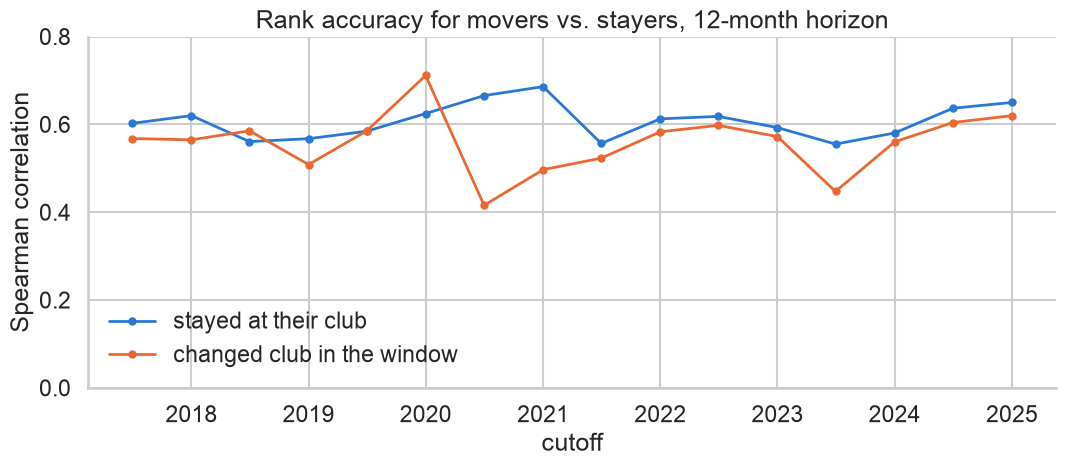

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for flag, color, label in [(False, BLUE, "stayed at their club"), (True, ORANGE, "changed club in the window")]:
    rows = by_transfer[by_transfer["transferred"] == flag].sort_values("cutoff")
    ax.plot(rows["cutoff"], rows["spearman"], color=color, linewidth=2, marker="o", markersize=5, label=label)
ax.set_ylim(0, 0.8)
ax.set_ylabel("Spearman correlation")
ax.set_xlabel("cutoff")
ax.set_title("Rank accuracy for movers vs. stayers, 12-month horizon")
ax.legend(frameon=False, loc="lower left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The worry doesn't hold. About 29% of evaluated players changed club inside the window, and the model ranks the *other* 71% better, not worse: Spearman 0.61 for players who stayed against 0.56 for those who moved, with a lower error and better direction accuracy too. That pattern holds at 14 of the 16 cutoffs; the two exceptions (2020 and 2025) are the two cutoffs where movers were unusually well predicted, not where stayers failed.

So the skill is in reading age, form and valuation trajectory, and a transfer mostly adds noise on top: movers have a higher average realised change (+38% vs +23%) and a much wider spread, which is the fee landing wherever the negotiation ended. One nuance worth keeping in mind: movers are still a big enough slice that a scout using the top of the list would see plenty of them, and the model is *less* reliable about exactly those players.